# Try the DecoKiller Module

In [ ]:
using Revise
using Latexify
using LinearAlgebra
using StatsBase
using Plots
using Plots.Measures
using Random

includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
# Utility function for plotting
includet("../julia/src/custom_plots.jl")
includet("../julia/src/operators.jl")

ENV["JULIA_DEBUG"] = "DecoKiller"

using .DecoKiller

In [ ]:
cfg, state, logs = load_configuration("../configs/config.toml");

@info "Real noise: $(cfg.real_noise.name)"
@info "Current choice of noise: $(state.noise_options[state.choice.current].name)"
@debug "Reference recovery state σ: $(cfg.sigma)"
@debug "Starting state: $(ρ0=state.ρ0)"

In [64]:
# 1. Apply noise (update rho1 and create intermediate rho2_)
N = state.M_total
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
Nx = cfg.real_noise.supermap

@info Nx == N1
@info Nx == N2

ρ_free = unvec(cfg.real_noise.supermap * vec(state.ρ0))
ρ_rec_ = unvec(Nx * vec(state.ρ0))
ρ1 = unvec(N1 * vec(state.ρ0))
ρ2 = unvec(N2 * vec(state.ρ0))
ρ_rec_

┌ Info: false
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:7
┌ Info: true
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:8


8×8 Matrix{ComplexF64}:
  0.175751+0.0im             0.0+0.0im         …  0.0253081-0.0360445im
       0.0+0.0im        0.108083+0.0im                  0.0+0.0im
       0.0+0.0im             0.0+0.0im                  0.0+0.0im
       0.0+0.0im             0.0+0.0im                  0.0+0.0im
       0.0+0.0im             0.0+0.0im                  0.0+0.0im
       0.0+0.0im             0.0+0.0im         …        0.0+0.0im
       0.0+0.0im        0.015564+0.00994039im           0.0+0.0im
 0.0253081+0.0360445im       0.0+0.0im             0.175751+0.0im

In [65]:
# 2. Recovery
model = CollisionModel(N, cfg.sigma)
ρ_rec, η = apply_collision(model, ρ_rec_)
model1 = CollisionModel(N1, cfg.sigma)
ρ1, η1 = apply_collision(model, ρ1)
model2 = CollisionModel(N2, cfg.sigma)
ρ2, η2 = apply_collision(model, ρ2)


# 3. Logging
fid_initial = fidelity(state.ρ0, ρ_rec)
fid_ref = fidelity(cfg.sigma, ρ_rec)
fid_track = fidelity(state.ρ0, ρ_free)

@info "Fidelity wrt initial state: " fid_initial
@info "Fidelity wrt reference state: " fid_ref
@info "Fidelity of free evolution: " fid_track

┌ Info: Fidelity wrt initial state: 
│   fid_initial = 0.8417068929844639
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sdnNjb2RlLXJlbW90ZQ==.jl:15
┌ Info: Fidelity wrt reference state: 
│   fid_ref = 0.8450721945499233
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sdnNjb2RlLXJlbW90ZQ==.jl:16
┌ Info: Fidelity of free evolution: 
│   fid_track = 0.3517051126198521
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sdnNjb2RlLXJlbW90ZQ==.jl:17


In [66]:
# First, we extend the ancillas dimensionality
max_d_ancillas = 4^cfg.n_qubits
η, η1, η2 = [embed_state(ancilla, max_d_ancillas) for ancilla in (η, η1, η2)]
# and normalize them with the probabilities of their respective noise channels
η1 = state.noise_options[1].probability * η1
η2 = state.noise_options[2].probability * η2

w = discrimin(η, η1, η2)
@info "Probabilities of the POVM outputs:" w

povm = sample(cfg.rng, [1, 2], Weights(w))
@info "Measurement result:" povm


┌ Info: Probabilities of the POVM outputs:
│   w = [0.034809845602422416, 0.9651901543975776]
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sdnNjb2RlLXJlbW90ZQ==.jl:9
┌ Info: Measurement result:
│   povm = 2
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sdnNjb2RlLXJlbW90ZQ==.jl:12


In [67]:
# Update the remaining state variables
if povm == 1
    append!(state.choice.c1, 1)
    append!(state.choice.c2, 0)
    state.choice.c1_count += 1
elseif povm == 2
    append!(state.choice.c1, 0)
    append!(state.choice.c2, 1)
    state.choice.c2_count += 1
end

inertia = 2
diff = state.choice.c1_count - state.choice.c2_count

if state.choice.current == 1
    if diff < -inertia
        state.choice.current = 2
    end
else
    if diff > inertia
        state.choice.current = 1
    end
end

@info "Updated choice: " state.choice.current
@info state.noise_options[state.choice.current].name

# Now we build the Petz on the belief that the noise was always that of the current choice
omega = state.noise_options[state.choice.current].supermap_noise
chosen_model = CollisionModel(state.noise_options[state.choice.current].supermap, cfg.sigma)
P = kraus_to_superop(model.kraus_rec);

┌ Info: Updated choice: 
│   state.choice.current = 1
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sdnNjb2RlLXJlbW90ZQ==.jl:25
┌ Info: amplitude_damping
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sdnNjb2RlLXJlbW90ZQ==.jl:26


In [68]:
# Update noises
state.M_total = omega * P * state.M_total
N1 = state.noise_options[1].supermap_noise * P * N1
N2 = state.noise_options[2].supermap_noise * P * N2
# Update the truth
Nx = cfg.real_noise.supermap * P * Nx 

@info Nx == N1
@info Nx == N2

┌ Info: false
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sdnNjb2RlLXJlbW90ZQ==.jl:8
┌ Info: true
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sdnNjb2RlLXJlbW90ZQ==.jl:9


## Reset and add the temporal loop

Using specified real noise from config...


[ Info: Real noise: bitflip
[ Info: Current choice of noise: amplitude_damping
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1


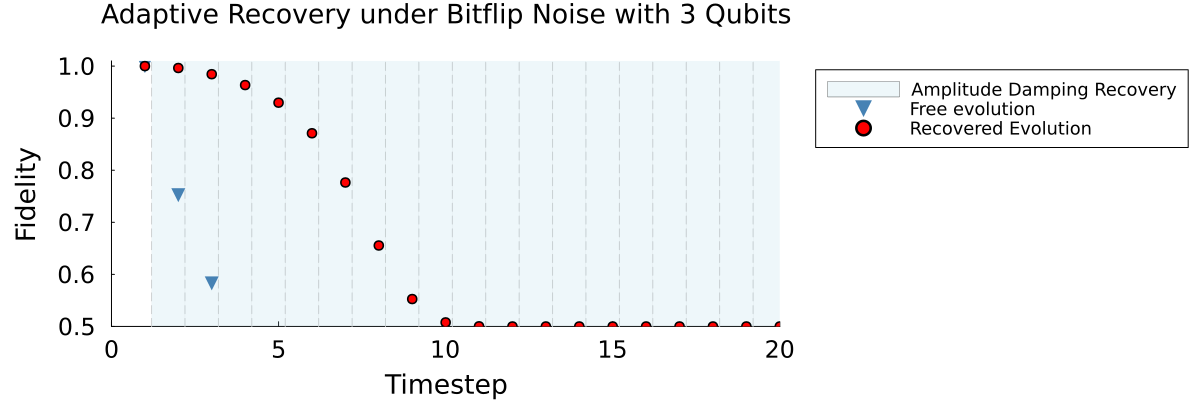

In [69]:

cfg, state, logs = load_configuration("../configs/config.toml");

# Change variable names for brevity
Ox = cfg.real_noise.supermap
O1 = state.noise_options[1].supermap
O2 = state.noise_options[2].supermap
N_free = cfg.real_noise.supermap
N = state.M_total
N1 = O1
N2 = O2
Nx = Ox

@info "Real noise: $(cfg.real_noise.name)"
@info "Current choice of noise: $(state.noise_options[state.choice.current].name)"
@debug "Reference recovery state σ: $(cfg.sigma)"
@debug "Starting state: $(ρ0=state.ρ0)"

variables = []

for n in 1:cfg.n_timesteps
    
    # 1. Apply noise (create intermediate rho_ before recovery)
    ρ_free = unvec(N_free * vec(state.ρ0))
    ρ_rec_ = unvec(Nx * vec(state.ρ0))
    ρ1 = unvec(N1 * vec(state.ρ0))
    ρ2 = unvec(N2 * vec(state.ρ0))
    
    # 2. Recovery
    model = CollisionModel(state.choice.current == 1 ? N1 : N2, cfg.sigma)
    P = kraus_to_superop(model.kraus_rec);

    ρ_rec, η = apply_collision(model, ρ_rec_)
    model1 = CollisionModel(N1, cfg.sigma)
    ρ1, η1 = apply_collision(model1, ρ1)
    model2 = CollisionModel(N2, cfg.sigma)
    ρ2, η2 = apply_collision(model2, ρ2)
	
	
    # 4. Measuring Fildelity and Logging
    fid_initial = fidelity(state.ρ0, ρ_rec)
    fid_track = fidelity(state.ρ0, ρ_free)
	
    @debug "Fidelity wrt initial state: $(fidelity_recovery=fid_initial)"
    @debug "Fidelity of free evolution: $(fidelity_free=fid_track)"
    
    push!(logs.ref_fidelities, fid_track)
    push!(logs.fidelities, fid_initial)
    
    # 5. Update noises for the next iteration
    push!(variables, [Nx, N1, N2, P])  # save superoperators at current step
    Nx = cfg.real_noise.supermap * P * Nx
    N1 = O1 * P * N1
    N2 = O2 * P * N2
    N_free = cfg.real_noise.supermap * N_free
	
    # 6. Compare output ancillas
	# First, we extend the ancillas dimensionality
	max_d_ancillas = 4^cfg.n_qubits
	η, η1, η2 = [embed_state(ancilla, max_d_ancillas) for ancilla in (η, η1, η2)]
	# and normalize them with the probabilities of their respective noise channels
	η1 = state.noise_options[1].probability * η1
	η2 = state.noise_options[2].probability * η2
    w = discrimin(η, η1, η2)
    @debug "Probabilities of the POVM outputs: $w"

    povm = sample(cfg.rng, [1, 2], Weights(w))
    @debug "Measurement result: $povm"

    # 7. Update guess for the next iteration
    if povm == 1
        append!(state.choice.c1, 1)
        append!(state.choice.c2, 0)
        state.choice.c1_count += 1
    elseif povm == 2
        append!(state.choice.c1, 0)
        append!(state.choice.c2, 1)
        state.choice.c2_count += 1
    end

    inertia = 1
    diff = state.choice.c1_count - state.choice.c2_count

    # The previous-step choice changes only if there is enough inertia in the opposing choice
    # Positive `diff` means that c1 is leading, negative means that c2 is leading
    if state.choice.current == 1
        if diff < -inertia
            state.choice.current = 2
        end
    else
        if diff > inertia
            state.choice.current = 1
        end
    end
	append!(state.choice.current_choices, state.choice.current)

    @info "Updated choice: " new_choice=state.choice.current
    
end

plot_autorecovery(state, cfg, logs; ylims=[0.5, 1.01])

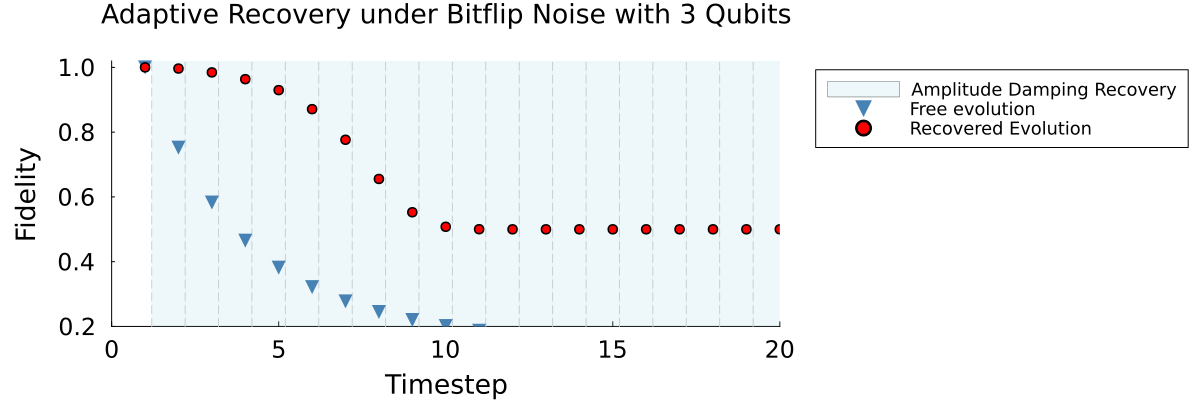

In [70]:
plot_autorecovery(state, cfg, logs; ylims=[0.2, 1.02])

## Working Example
We do it step by step with real numbers

In [ ]:
# We start with a peculiar σ state
function initialize_systems(n_qubits, beta, p, x; verbose=false)

	sigma = thermal_state(n_qubits, beta)
	sigma = sigma / tr(sigma)  # Normalize to ensure it's a valid density matrix

	encoded_ρ0 = p * ggg * ggg' + (1 - p) * eee * eee' + x * ggg * eee' + x' * eee * ggg'

	ρ0 = sigma + encoded_ρ0
	ρ0 = ρ0 / tr(ρ0)  # Normalize to ensure it's a valid density matrix

	if verbose
		if abs(p * (1 - p) - (x * x')) < 0
			throw(ArgumentError("The state is not physical. Please check the parameters p and x."))
		else
			display(latexify(ρ0))
			display(latexify(sigma))
		end
	end

	return ρ0, sigma, encoded_ρ0
end

initialize_systems(3, 4.0, 0.6, 0.1 + 0.1im; verbose=true);

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.44999991559864744+0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.05-0.05\\mathit{i} \\\\\n0.0\\mathit{i} & 2.8133784181693818e-8+0.0\\mathit{i} & 0.0\\mathit{i} " ⋯ 757 bytes ⋯ "thit{i} & 0.0\\mathit{i} & 2.8133784181693818e-8+0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n0.05+0.05\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.5499999155986475+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.49999983119729485+0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n-0.0\\mathit{i} & 5.6267568363387636e-8+0.0\\mathit{i} & 0.0\\mathit{i} & 0.0" ⋯ 774 bytes ⋯ "t{i} & -0.0\\mathit{i} & 5.6267568363387636e-8+0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n-0.0\\mathit{i} & -0.0\\mathit{i} & -0.0\\mathit{i} & -0.0\\mathit{i} & -0.0\\mathit{i} & -0.0\\mathit{i} & -0.0\\mathit{i} & 0.49999983119729485+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

(ComplexF64[0.44999991559864744 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.05 - 0.05im; 0.0 + 0.0im 2.8133784181693818e-8 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 2.8133784181693818e-8 + 0.0im 0.0 + 0.0im; 0.05 + 0.05im 0.0 + 0.0im … 0.0 + 0.0im 0.5499999155986475 + 0.0im], ComplexF64[0.49999983119729485 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 - 0.0im 5.6267568363387636e-8 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 - 0.0im 0.0 - 0.0im … 5.6267568363387636e-8 + 0.0im 0.0 + 0.0im; 0.0 - 0.0im 0.0 - 0.0im … 0.0 - 0.0im 0.49999983119729485 + 0.0im])

In [ ]:
function create_experiment(n_qubits, beta, p, x, seed)
	ρ0, sigma, encoded_ρ0 = initialize_systems(n_qubits, beta, p, x)
	
	dt = 0.2  # Time interval for noise application
	gamma = 1.0  # Noise strength
	noise1 = NoiseObj("amplitude_damping", 0.3, sigma, gamma, dt)
	noise2 = NoiseObj("bitflip", 0.7, sigma, gamma, dt)
	real_noise = deepcopy(noise2)
	# Initial choice: noise1
	choice = ChoiceSystem([1], [0], 1, 0, 1, [1])

	n_timesteps = 10
	n_states = 1
	rng = Xoshiro(42)
	cfg = RecoveryConfig(
		"example", sigma, "auto", real_noise,
		n_qubits, n_timesteps, n_states, seed, rng, dt
	)
	state = RecoveryState(
		copy(ρ0), copy(ρ0), copy(ρ0),
		deepcopy(noise1), copy(noise1.supermap_noise), choice, [noise1, noise2]
	)
	logs = RecoveryLogs()

	mkpath("../experiments/example/visualization")

	return cfg, state, logs, encoded_ρ0
end

cfg, state, logs, encoded_ρ0 = create_experiment(3, 4.0, 0.6, 0.1 + 0.1im, 42)

@info "Real noise: $(cfg.real_noise.name)"
@info "Current choice of noise: $(state.noise_options[state.choice.current].name)"
@debug "Reference recovery state σ: $(cfg.sigma)"
@debug "Starting state: $(ρ0=state.ρ0)"

┌ Info: Real noise: bitflip
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sdnNjb2RlLXJlbW90ZQ==.jl:32
┌ Info: Current choice of noise: amplitude_damping
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sdnNjb2RlLXJlbW90ZQ==.jl:33


┌ Debug: Fidelity wrt initial state: 
│   fid_initial = 0.9863519514007222
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/julia/src/adaptive_recovery.jl:118
┌ Debug: Fidelity of free evolution: 
│   fid_track = 0.7530932782492041
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/julia/src/adaptive_recovery.jl:119
┌ Debug: Probabilities of the POVM outputs: [0.002128990132854523, 0.9978710098671455]
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/julia/src/adaptive_recovery.jl:140
┌ Debug: Measurement result: 2
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/julia/src/adaptive_recovery.jl:143
┌ Debug: Updated choice: 
│   new_choice = 1
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/julia/src/adaptive_recovery.jl:172
┌ Debug: Fidelity wrt initial state: 
│   fid_initial = 0.9570401022504428
└ @ Main.DecoKiller /home/fedesss/UNIPA/COLL

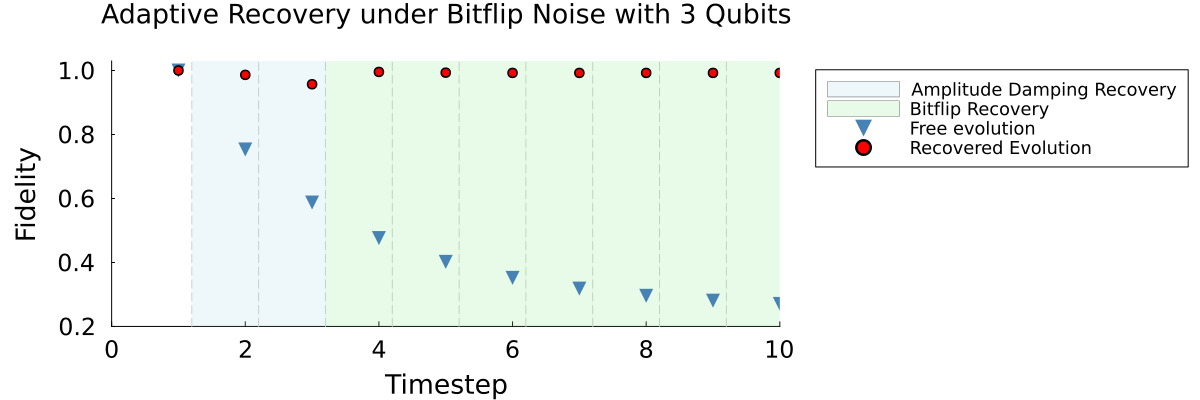

In [ ]:
# Reinitialize the state and logs for the experiment
cfg, state, logs = create_experiment(3, 4.0, 0.6, 0.1 + 0.1im, 42)

# Change variable names for brevity
Ox = cfg.real_noise.supermap
O1 = state.noise_options[1].supermap
O2 = state.noise_options[2].supermap
N_free = cfg.real_noise.supermap
N = state.M_total
N1 = O1
N2 = O2
Nx = Ox

g0 = [0.0 + 0.0im; 1.0]
e1 = [1.0 + 0.0im; 0.0]

ggg = foldl(kron, [g0 for _ in 1:cfg.n_qubits])
eee = foldl(kron, [e1 for _ in 1:cfg.n_qubits])
projector = ggg * ggg' + eee * eee'  # Projector onto the codespace
fs = []
for step in 1:cfg.n_timesteps
	step_recovery!(step, state, cfg, logs)
	N = logs.maps[end].Nx
	rho = unvec(N * vec(state.ρ0))
	rho = projector * rho * projector'
	rho = rho / tr(rho)
	fid = fidelity(rho, encoded_ρ0)
	push!(fs, fid)
end

g1 = plot_autorecovery(state, cfg, logs; ylims=[0.2, 1.03], show=false)

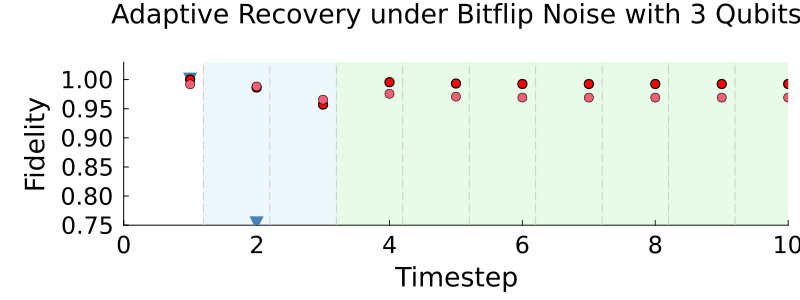

In [69]:
g2 = scatter(g1, fs; xlabel="Timestep", ylabel="Fidelity", legend=false, size=(800, 300), markersize=5)
ylims!(g2, 0.75, 1.03)

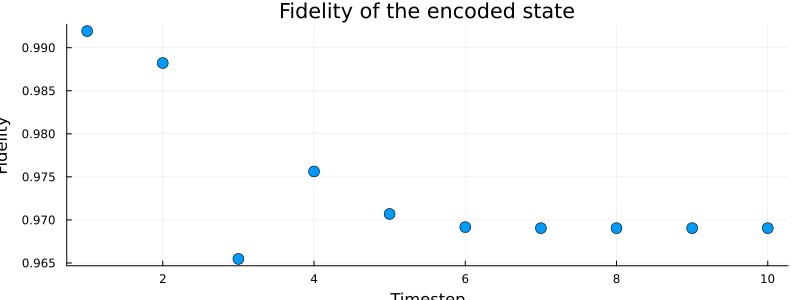

In [70]:
g = scatter(fs; xlabel="Timestep", ylabel="Fidelity", title="Fidelity of the encoded state", legend=false, size=(800, 300), markersize=6)
# savefig(g, "../experiments/example/visualization/fidelity_encoded_state.png")
# savefig(g, "../experiments/example/visualization/fidelity_encoded_state.pdf")